In [ ]:
# Customer Segmentation Using RFM Analysis

This project analyzes online retail transaction data to identify valuable customer segments using Recency, Frequency, and Monetary (RFM) analysis. The goal is to understand customer behavior and recommend targeted marketing strategies for different customer groups.

In [ ]:
## 1. Business Problem

An online retailer wants to better understand its customers and determine which groups should receive different marketing strategies.

The main business questions are:

- Which customers are the most valuable?
- Which customers are purchasing frequently?
- Which valuable customers may be at risk of becoming inactive?
- Which customer segments generate the most revenue?
- What marketing actions should be recommended for each segment?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [ ]:
## 2. Import Libraries

The analysis uses Pandas for data manipulation, NumPy for numerical operations, and Matplotlib for data visualization.

In [ ]:
## 3. Load and Inspect the Dataset

The dataset contains transaction-level information including invoice numbers, product quantities, unit prices, transaction dates, customer IDs, and customer countries.

In [2]:
df = pd.read_excel("Online Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.shape

(541909, 8)

In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [ ]:
## 4. Data Cleaning

To prepare the dataset for customer-level RFM analysis, I:

- Removed transactions with missing Customer IDs
- Removed cancelled orders
- Kept only transactions with positive quantities
- Kept only transactions with positive unit prices
- Removed exact duplicate rows

In [12]:
df = df.dropna(subset=["CustomerID"])

In [13]:
df["CustomerID"].isnull().sum()

np.int64(0)

In [15]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [17]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [18]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [19]:
df["Quantity"].describe()

count    397924.000000
mean         13.021823
std         180.420210
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [20]:
df = df[df["Quantity"]>0]

In [21]:
df["Quantity"]

0          6
1          6
2          8
3          6
4          6
          ..
541904    12
541905     6
541906     4
541907     4
541908     3
Name: Quantity, Length: 397924, dtype: int64

In [24]:
df["Quantity"] > 0

0         True
1         True
2         True
3         True
4         True
          ... 
541904    True
541905    True
541906    True
541907    True
541908    True
Name: Quantity, Length: 397924, dtype: bool

In [27]:
df = df[df["Quantity"] > 0]

In [28]:
df["Quantity"].min()

np.int64(1)

In [29]:
df.shape

(397924, 8)

In [30]:
df["UnitPrice"].describe()

count    397924.000000
mean          3.116174
std          22.096788
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [31]:
df = df[df["UnitPrice"] > 0]

In [32]:
df["UnitPrice"]

0         2.55
1         3.39
2         2.75
3         3.39
4         3.39
          ... 
541904    0.85
541905    2.10
541906    4.15
541907    4.15
541908    4.95
Name: UnitPrice, Length: 397884, dtype: float64

In [34]:
df["UnitPrice"] > 0

0         True
1         True
2         True
3         True
4         True
          ... 
541904    True
541905    True
541906    True
541907    True
541908    True
Name: UnitPrice, Length: 397884, dtype: bool

In [35]:
df = df[df["UnitPrice"] > 0]

In [36]:
df["UnitPrice"].min()

np.float64(0.001)

In [37]:
df.duplicated().sum()

np.int64(5192)

In [38]:
df = df.drop_duplicates()

In [ ]:
## 5. Revenue Calculation

Revenue was calculated for each transaction by multiplying the quantity purchased by the unit price.

Revenue = Quantity × Unit Price

In [39]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [40]:
df["Revenue"]

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
541904    10.20
541905    12.60
541906    16.60
541907    16.60
541908    14.85
Name: Revenue, Length: 392692, dtype: float64

In [41]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [42]:
df["Revenue"].sum()

np.float64(8887208.894000001)

In [43]:
df["CustomerID"].nunique()

4338

In [44]:
df["CustomerID"]

0         17850.0
1         17850.0
2         17850.0
3         17850.0
4         17850.0
           ...   
541904    12680.0
541905    12680.0
541906    12680.0
541907    12680.0
541908    12680.0
Name: CustomerID, Length: 392692, dtype: float64

In [45]:
df["InvoiceNo"].nunique()

18532

In [48]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [ ]:
## 6. RFM Analysis

RFM analysis evaluates customers using three dimensions:

- Recency: How recently the customer purchased
- Frequency: How many unique orders the customer placed
- Monetary: How much total revenue the customer generated

Lower Recency is better, while higher Frequency and Monetary values are better.

In [49]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [57]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

In [58]:
rfm.head()

,InvoiceDate,InvoiceNo,Revenue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [81]:
rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "Revenue": "Monetary"
}, inplace=True)

In [82]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,M_Score
CustomerID,,,,,
12346.0,326,1,77183.60,1,5
12347.0,2,7,4310.00,5,5
12348.0,75,4,1797.24,2,4
12349.0,19,1,1757.55,4,4
12350.0,310,1,334.40,1,2


In [63]:
rfm.describe()

,Recency,InvoiceNo,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [ ]:
## 7. RFM Scoring

Customers were divided into five groups for each RFM dimension.

- Recency score: 5 = most recent
- Frequency score: 5 = most frequent
- Monetary score: 5 = highest spending

In [65]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

In [84]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [75]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [85]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [86]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,M_Score,F_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,5,1
12347.0,2,7,4310.00,5,5,5
12348.0,75,4,1797.24,2,4,4
12349.0,19,1,1757.55,4,4,1
12350.0,310,1,334.40,1,2,1


In [ ]:
## 8. Customer Segmentation

Customers were grouped into marketing segments based on their RFM scores.

The segments include:

- Champions
- Loyal Customers
- Potential Loyalists
- At Risk
- Lost Customers
- Other

In [87]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [88]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,M_Score,F_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,5,1,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,4,1,414
12350.0,310,1,334.40,1,2,1,112


In [90]:
def segment_customer(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >=4 and f>=4 and m >=4:
        return "Champions"

    elif f >= 4 and m >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >=2:
        return "Potential Loyalists"

    elif r <=2 and f <=3 and m >=3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Lost Customers"

    else:
        return "Other"
        

In [94]:
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
## 9. Results

The RFM segmentation produced six customer groups based on differences in purchase recency, frequency, and monetary value.

In [95]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,M_Score,F_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,5,1,115,At Risk
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
12349.0,19,1,1757.55,4,4,1,414,Other
12350.0,310,1,334.40,1,2,1,112,Lost Customers


In [96]:
rfm["Segment"].value_counts()

Segment
Other                  1026
Champions               957
Lost Customers          821
Potential Loyalists     674
At Risk                 457
Loyal Customers         403
Name: count, dtype: int64

In [97]:
segemnt_counts = rfm["Segment"].value_counts()

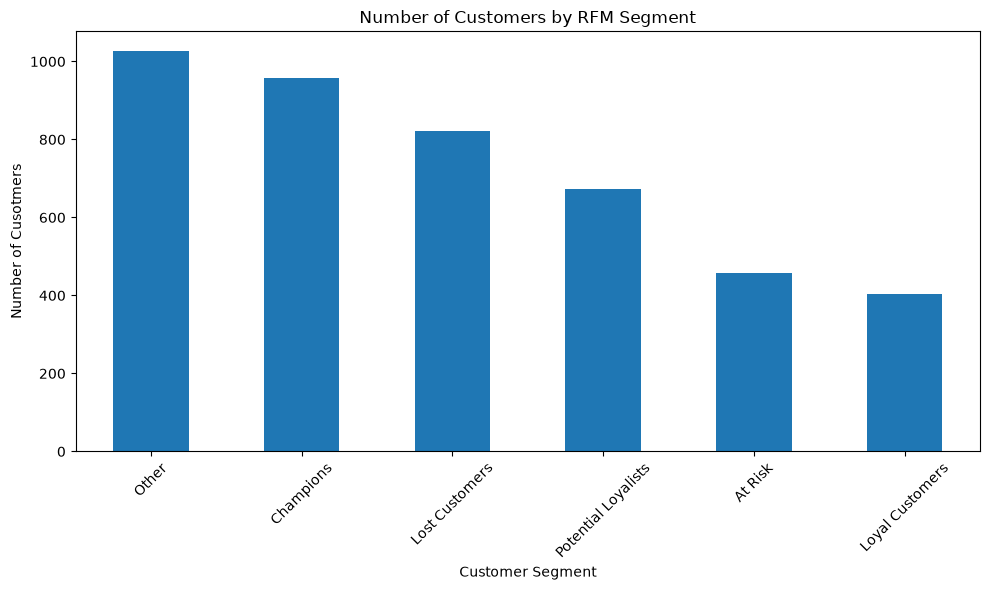

In [99]:
plt.figure(figsize=(10, 6))

segemnt_counts.plot(kind="bar")

plt.title("Number of Customers by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Cusotmers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [107]:
Segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

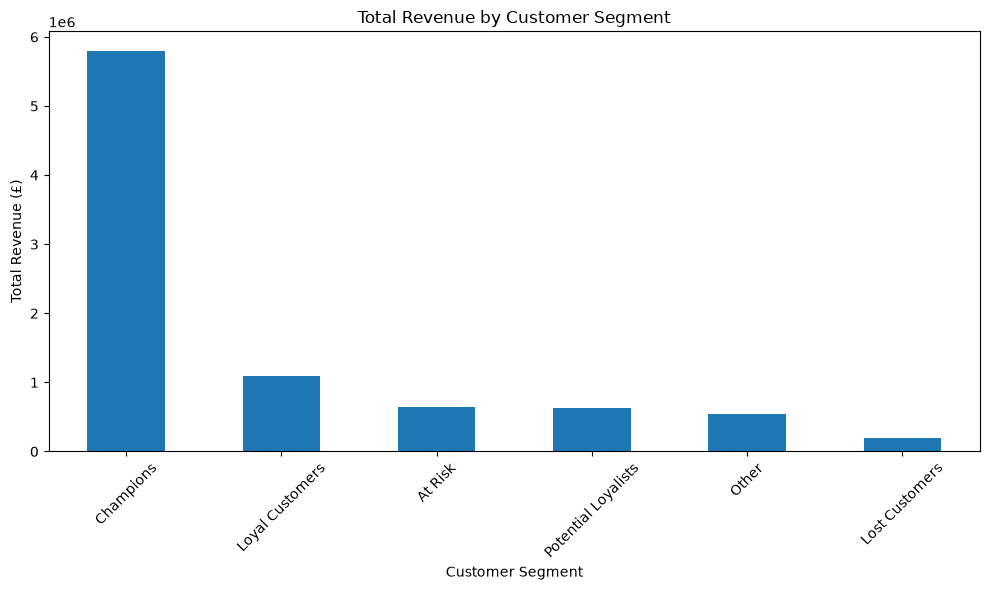

In [108]:
plt.figure(figsize=(10, 6))

segment_revenue.plot(kind="bar")

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [109]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Total_Revenue=("Monetary", "sum"),
    Average_Revenue=("Monetary", "mean"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean")
)

In [110]:
segment_summary["Revenue_Share"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
)

In [113]:
segment_summary["Customer_Share"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
)

In [114]:
segment_summary.sort_values("Total_Revenue", ascending=False)

,Customers,Total_Revenue,Average_Revenue,Average_Recency,Average_Frequency,Revenue_Share,Customer_Share
Segment,,,,,,,
Champions,957,5791640.740,6051.871202,12.824451,11.123302,65.168275,22.060858
Loyal Customers,403,1089913.960,2704.501141,81.751861,6.024814,12.263850,9.289995
At Risk,457,649630.912,1421.511842,168.345733,1.800875,7.309729,10.534809
Potential Loyalists,674,628594.971,932.633488,16.786350,2.550445,7.073030,15.537114
Other,1026,539798.820,526.119708,78.623782,2.008772,6.073885,23.651452
Lost Customers,821,187629.491,228.537748,228.121803,1.042631,2.111231,18.925772


In [116]:
comparison = segment_summary[
    ["Customer_Share", "Revenue_Share"]
    ]

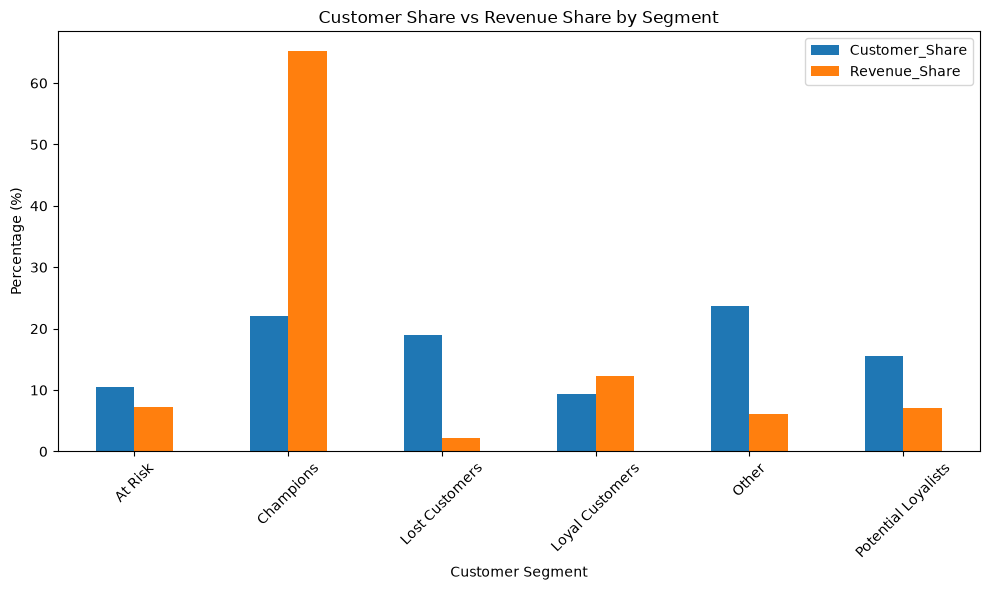

In [121]:
comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Share vs Revenue Share by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

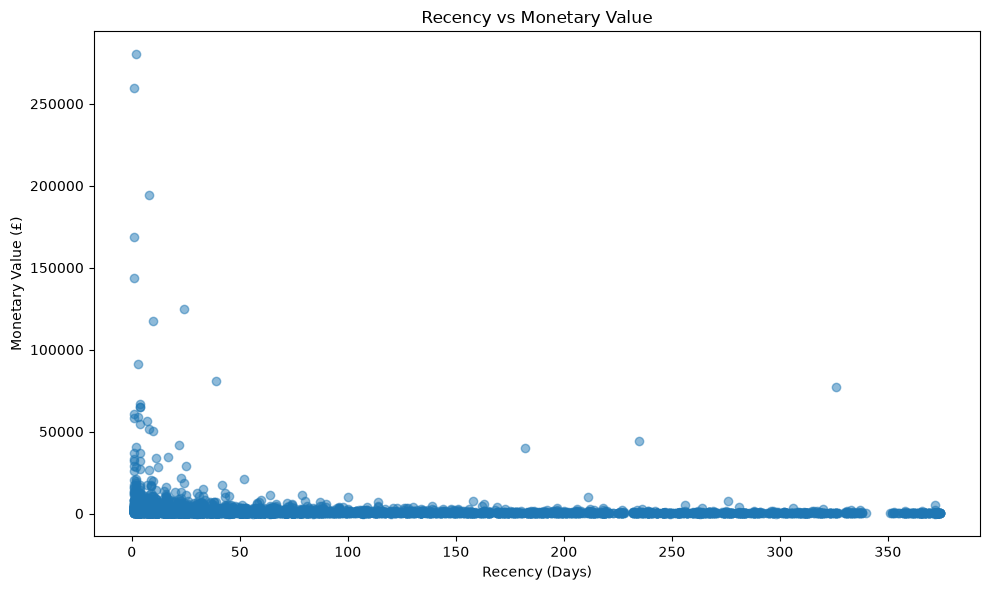

In [122]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    alpha=0.5
)

plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value (£)")
plt.title("Recency vs Monetary Value")

plt.tight_layout()
plt.show()

In [126]:
segment_strategy = pd.DataFrame({
    "Segment":[
        "Champions",
        "Loyal Customers",
        "Potential Loyalists",
        "At Risk",
        "Lost Customers",
        "Other"
    ],
    "Marketing_Action":[
        "Offer VIP rewards, early access, and referral incentives",
        "Use loyalty rewards, cross-sell, and personalized recommendations",
        "Encourage repeat purchases with post-purchase emails, and targeted offers",
        "Launch win-back campaigns with personalized reminders or incentives",
        "Use low-cost reactivation campaigns or reduce marketing spend",
        "Test additional segmentation and targeted messaging"
    ]
})

In [127]:
final_summary = segment_summary.reset_index().merge(
    segment_strategy,
    on="Segment",
    how="left"
)

In [128]:
final_summary

,Segment,Customers,Total_Revenue,Average_Revenue,Average_Recency,Average_Frequency,Revenue_Share,Customer_Share,Marketing_Action
0,At Risk,457,649630.912,1421.511842,168.345733,1.800875,7.309729,10.534809,Launch win-back campaigns with personalized re...
1,Champions,957,5791640.740,6051.871202,12.824451,11.123302,65.168275,22.060858,"Offer VIP rewards, early access, and referral ..."
2,Lost Customers,821,187629.491,228.537748,228.121803,1.042631,2.111231,18.925772,Use low-cost reactivation campaigns or reduce ...
3,Loyal Customers,403,1089913.960,2704.501141,81.751861,6.024814,12.263850,9.289995,"Use loyalty rewards, cross-sell, and personali..."
4,Other,1026,539798.820,526.119708,78.623782,2.008772,6.073885,23.651452,Test additional segmentation and targeted mess...
5,Potential Loyalists,674,628594.971,932.633488,16.786350,2.550445,7.073030,15.537114,Encourage repeat purchases with post-purchase ...


In [129]:
final_summary.to_csv("rfm_segment_summary.csv", index=False)

In [132]:
rfm.to_csv("rfm_customer_segments.csv")

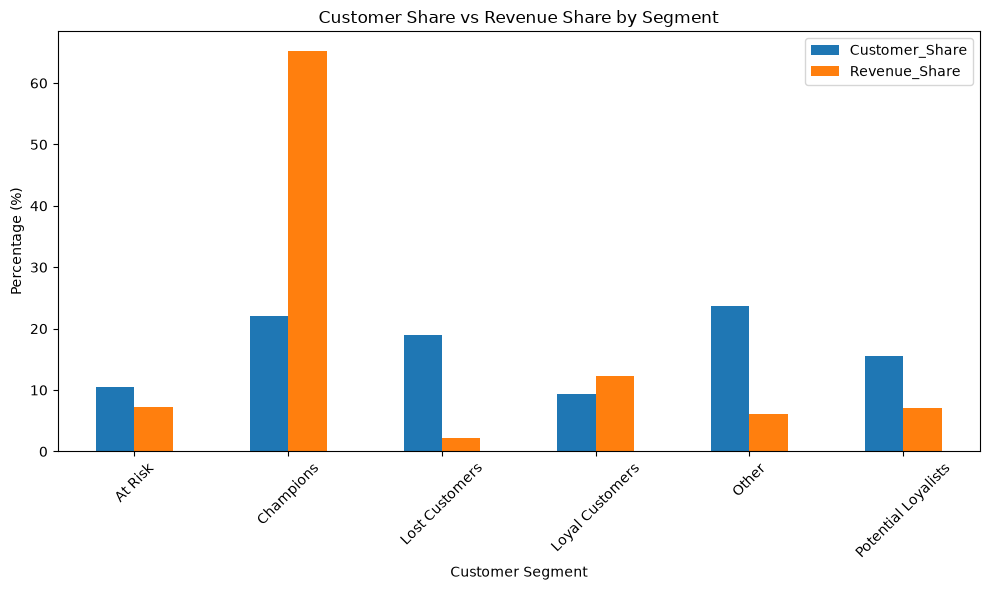

In [135]:
# Create a bar chart comparing customer share and revenue share by segment
comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Share vs Revenue Share by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "customer_share_vs_revenue_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

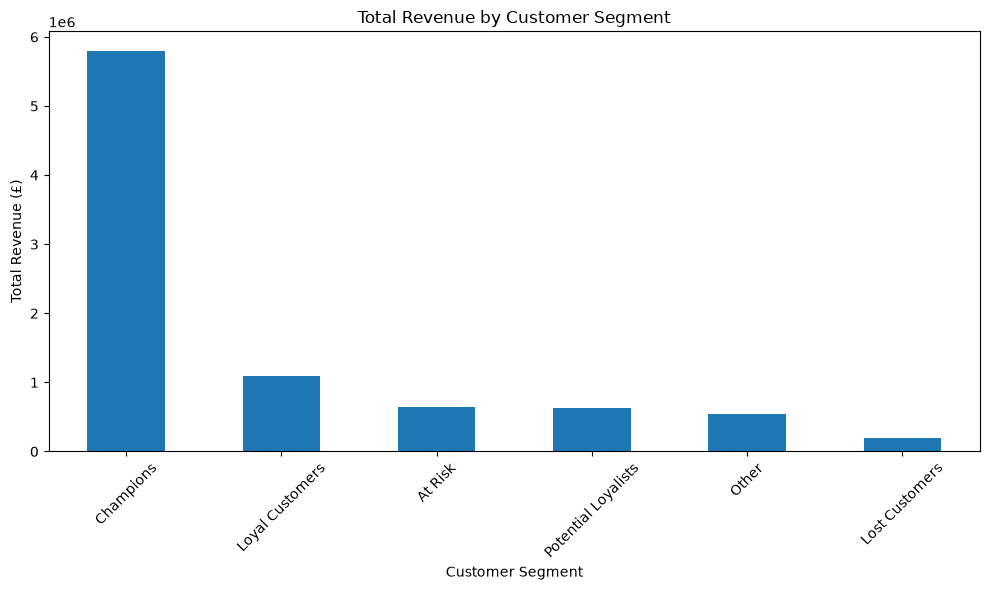

In [136]:
# Create a new figure for the revenue chart
plt.figure(figsize=(10, 6))

# Plot total revenue for each customer segment
segment_revenue.plot(kind="bar")

# Add chart title and axis labels
plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")

# Rotate segment labels for readability
plt.xticks(rotation=45)

# Adjust spacing
plt.tight_layout()

# Save the chart as a high-resolution PNG file
plt.savefig(
    "revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

In [139]:
# Count the number of customers in each RFM segment
segment_counts = rfm["Segment"].value_counts()

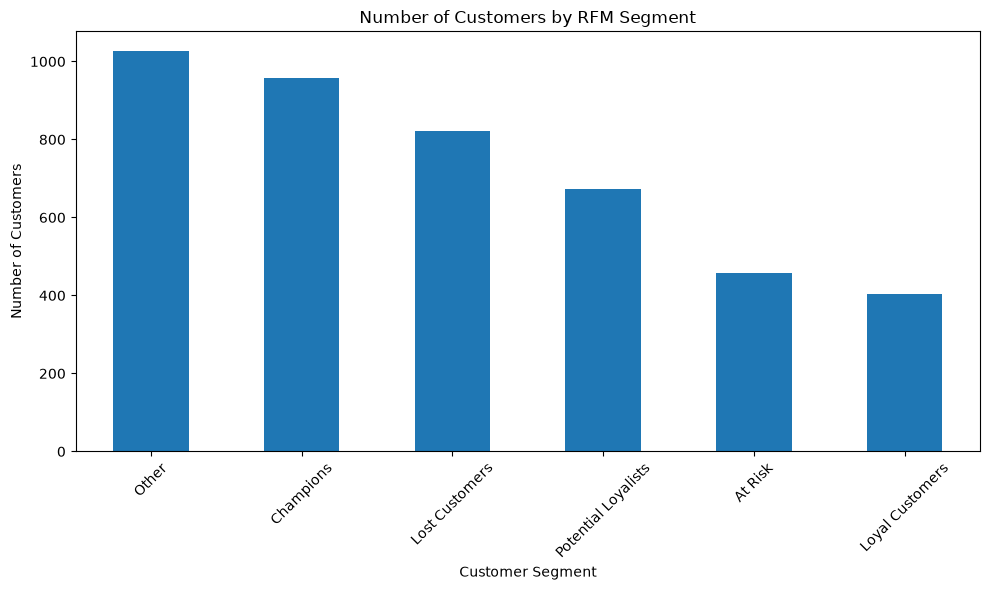

In [140]:
# Create a new figure for customer segment counts
plt.figure(figsize=(10, 6))

# Plot the number of customers in each RFM segment
segment_counts.plot(kind="bar")

# Add chart title and axis labels
plt.title("Number of Customers by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

# Rotate segment labels for readability
plt.xticks(rotation=45)

# Adjust spacing so labels are not cut off
plt.tight_layout()

# Save the chart as a high-resolution PNG file
plt.savefig(
    "customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()